# Simulation of a positron-induced Muon Source

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

<center>
    <img src="Feynman_Diagram.svg" width="400" style="filter: invert(100%)">
</center>

\begin{split}
iM &= \overline{U}_{r'}(k) (ie\gamma^{\mu}) V_{s'}(k') \left( \frac{-i\eta_{\mu\nu}}{s} \right) \overline{V}_{s}(p') (ie\gamma^{\nu}) U_{r}(p) \\
   &= \frac{ie^2}{s} (\overline{U}_{r'}(k) \gamma^{\mu} V_{s'}(k') \overline{V}_{s}(p') \gamma_{\mu} U_{r}(p))
\end{split}


$\providecommand{\slashed}[1]{#1 \kern-0.5em /}$
$|\overline{M}|^2 = \frac{1}{4} \sum_{spins} M M^* = \frac{e^4}{4 s^2} Tr((\slashed{k}'-m) \gamma^\nu (\slashed{k}+m) \gamma^\mu) Tr((\slashed{p}+m) \gamma_\nu (\slashed{p}'-m) \gamma_\mu)$

$Tr((\slashed{k}'-m) \gamma^\nu (\slashed{k}+m) \gamma^\mu) = 4 (k^\mu k'^\nu + k^\nu k'^\mu - (k \cdot k' + m_\mu^2) \eta^{\nu\mu})$

$Tr((\slashed{p}+m) \gamma_\nu (\slashed{p}'+m) \gamma_\mu) = 4 (p_\mu p'_\nu + p_\nu p'_\mu - (p \cdot p' + m_e^2) \eta_{\nu\mu})$


(Note: $m_\mu^2$ is not Einstein indexing)

$|\overline{M}|^2 = \frac{8 e^4}{s^2} ((k \cdot p)(k' \cdot p') + (k \cdot p')(k' \cdot p) + m_e^2 (k \cdot k') + m_\mu^2 (p \cdot p') + 2 m_e^2 m_\mu^2)$

$m_e$ negligible ?

Kinematic

$ s = (p + p')^2 = 2 m_e^2 + 2 p \cdot p' \Rightarrow p \cdot p' = \frac{s}{2} - m_e^2 $

$ k \cdot k' = \frac{s}{2} - m_\mu^2$

$ p \cdot k = $

$ p \cdot k' = $

If $m_e = 0$

$\left( \frac{d\sigma}{d\omega} \right)_{CM} = \frac{e^4}{64 \pi^2 s} \sqrt{\left(1 - \frac{4 m_\mu^2}{s} \right)} \left(\left(1 + \frac{4 m_\mu^2}{s} \right) + \left(1 - \frac{4 m_\mu^2}{s} \right) \cos{\theta}^2 \right) $

$(p, 0, 0, p)$

$p_\mu p^\mu = m_\gamma^2 = 0 = E^2 - p^2$

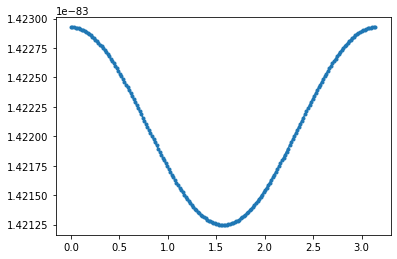

In [31]:
e = 1.602176634 * 10**(-19)
mass_e = 0.51099895069
mass_mu = 105.6583755

def cross_section(s, omega):
    ratio = 4 * mass_mu**2 / s
    return e**4 / (32 * np.pi * s) * np.sqrt(1 - ratio) * (1 + ratio + (1 - ratio) * np.cos(omega)**2)

def cross_section_norm(s, cos):
    ratio = 4 * mass_mu**2 / s
    beta = np.sqrt(1 - ratio)
    return 3 / (4*(3 - beta**2)) * (1 + cos**2 + (1 - beta**2) * (1 - cos**2))

s = 4 * mass_mu**2 + mass_mu * 1     # should be greater than 4 mass_mu**2
l = np.linspace(0, np.pi, 200, endpoint=True)
plt.plot(l, cross_section(s, l), marker=".")
#plt.ylim(-10**-20, 10**-20)

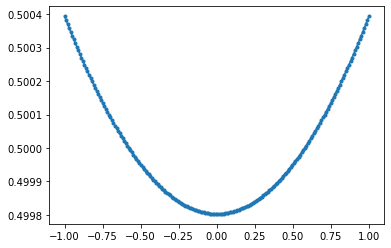

In [32]:
cos_linspace = np.linspace(-1, 1, 200, endpoint=True)
plt.plot(cos_linspace, cross_section_norm(s, cos_linspace), marker=".")


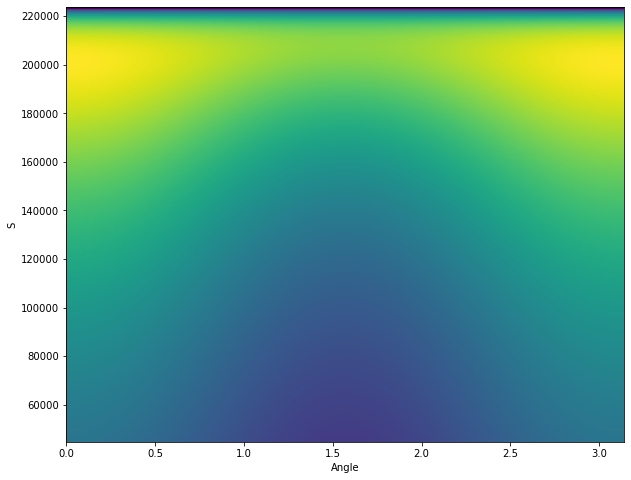

In [33]:
s_space = np.linspace(s, 5 * s, 200, endpoint=True)

xv, yv = np.meshgrid(l, s_space)

plt.figure(figsize=(10, 8))
plt.imshow(cross_section(yv, xv), extent=[0, np.pi, s, 5*s], aspect='auto')
plt.xlabel("Angle")
plt.ylabel("S")
plt.show()

999177


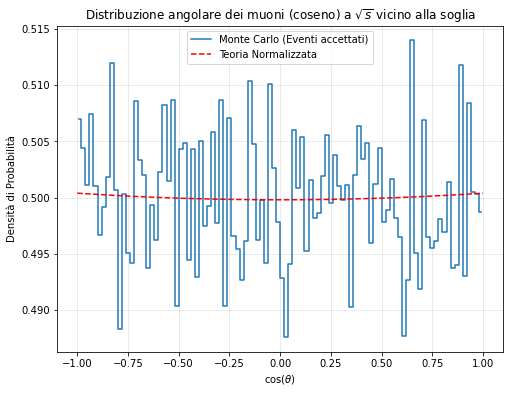

In [34]:
n = 1000000
u = np.random.uniform(-1, 1, n)
r = np.random.uniform(0, cross_section_norm(s, 1), n)
v = u[r < cross_section_norm(s, u)]
print(len(v))

# 3. Plot di confronto
plt.figure(figsize=(8, 6))

# Istogramma del Monte Carlo (Normalizzato con density=True)
hist, bin_edges = np.histogram(v, bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.
plt.step(bin_centers, hist, where='mid', label="Monte Carlo (Eventi accettati)")

# Curva teorica normalizzata
cos_range = np.linspace(-1, 1, 50)
plt.plot(cos_range, cross_section_norm(s, cos_range), 'r--', label="Teoria Normalizzata")

plt.xlabel(r"$\cos(\theta)$")
plt.ylabel("Densità di Probabilità")
plt.title(r"Distribuzione angolare dei muoni (coseno) a $\sqrt{s}$ vicino alla soglia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

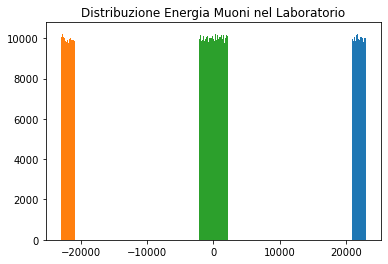

In [35]:
E_pos = (s - 2 * mass_e**2) / (2 * mass_e)
p_pos = np.sqrt(E_pos**2 - mass_e**2)
gamma = (E_pos + mass_e) / np.sqrt(s)
beta = p_pos / (E_pos + mass_e)

phi = np.random.uniform(0, 2*np.pi, len(v))
p_mod = np.sqrt(s/4 - mass_mu**2)
px_cm_1 = p_mod * np.sqrt(1 - v**2) * np.cos(phi)
py_cm_1 = p_mod * np.sqrt(1 - v**2) * np.sin(phi)
pz_cm_1 = p_mod * v
E_cm_1 = np.sqrt(s)/2

px_cm_2 = -1 * p_mod * np.sqrt(1 - v**2) * np.cos(phi)
py_cm_2 = -1 * p_mod * np.sqrt(1 - v**2) * np.sin(phi)
pz_cm_2 = -1 * p_mod * v
E_cm_2 = np.sqrt(s)/2

pz_lab_1 = gamma * (pz_cm_1 + beta * E_cm_1)
E_lab_1 = gamma * (E_cm_1 + beta * pz_cm_1)

pz_lab_2 = gamma * (pz_cm_2 + beta * E_cm_2)
E_lab_2 = gamma * (E_cm_2 + beta * pz_cm_2)

plt.hist(E_lab_1, bins=100)
plt.hist(-1.0* E_lab_2, bins=100)
plt.hist(E_lab_2 - E_lab_1, bins=100)
#plt.scatter(E_lab_1, E_lab_2, marker=".")
plt.title("Distribuzione Energia Muoni nel Laboratorio")
plt.show()
